In [1]:
from transformers import ViTForImageClassification, ViTImageProcessor
from PIL import Image
import torch

CHECKPOINT_PATH = "../Models/vit_crop/checkpoint-32110"

inference_model = ViTForImageClassification.from_pretrained(CHECKPOINT_PATH)
inference_processor = ViTImageProcessor.from_pretrained(CHECKPOINT_PATH)

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
inference_model = inference_model.to(device)
inference_model.eval()

print(f"Model loaded from {CHECKPOINT_PATH}")
print(f"Using device: {device}") 

/Users/armaanjagirdar/Projects/ML_Project/env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Model loaded from ../Models/vit_crop/checkpoint-32110
Using device: mps


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from lime import lime_image
from skimage.segmentation import mark_boundaries
import json

In [3]:
id_to_class = inference_model.config.id2label
class_to_id = inference_model.config.label2id

print(f"Number of classes: {len(id_to_class)}")
print(f"Classes loaded from model configuration")

Number of classes: 60
Classes loaded from model configuration


In [4]:
def predict_fn(images):
    batch_images = []
    for img in images:
        pil_img = Image.fromarray(img.astype('uint8'), 'RGB')
        batch_images.append(pil_img)
    
    inputs = inference_processor(images=batch_images, return_tensors="pt")
    inputs = {k: v.to(device) for k, v in inputs.items()}
    
    with torch.no_grad():
        outputs = inference_model(**inputs)
        probs = torch.nn.functional.softmax(outputs.logits, dim=-1)
    
    return probs.cpu().numpy()

Image loaded: ../dataset/images/Apple,Frog Eye Leaf Spot/plant_81319.jpg
Image shape: (299, 448, 3)


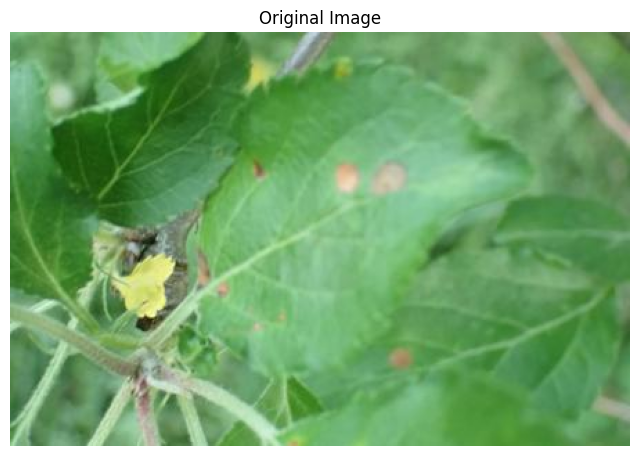

In [6]:
IMAGE_PATH = "../dataset/images/Apple,Frog Eye Leaf Spot/plant_81319.jpg"
image = Image.open(IMAGE_PATH).convert('RGB')
img_array = np.array(image)

print(f"Image loaded: {IMAGE_PATH}")
print(f"Image shape: {img_array.shape}")

plt.figure(figsize=(8, 6))
plt.imshow(image)
plt.title("Original Image")
plt.axis('off')
plt.show()

In [7]:
inputs = inference_processor(images=image, return_tensors="pt")
inputs = {k: v.to(device) for k, v in inputs.items()}

with torch.no_grad():
    outputs = inference_model(**inputs)
    probs = torch.nn.functional.softmax(outputs.logits, dim=-1)
    predicted_class_idx = probs.argmax(-1).item()
    confidence = probs[0, predicted_class_idx].item()

predicted_label = id_to_class[predicted_class_idx]

print(f"Predicted class: {predicted_label}")
print(f"Confidence: {confidence:.4f}")

Predicted class: Apple,Frog Eye Leaf Spot
Confidence: 1.0000


In [8]:
explainer = lime_image.LimeImageExplainer()

explanation = explainer.explain_instance(
    img_array,
    predict_fn,
    top_labels=5,
    hide_color=0,
    num_samples=1000  
)

100%|██████████| 1000/1000 [00:24<00:00, 41.50it/s]
/Users/armaanjagirdar/Projects/ML_Project/env/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/armaanjagirdar/Projects/ML_Project/env/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/armaanjagirdar/Projects/ML_Project/env/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/armaanjagirdar/Projects/ML_Project/env/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/armaanjagirdar/Projects/ML_Project/env/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/armaanjagirdar/Projects/ML_Project/env/lib/python3.10/site-packages/sklearn/utils/extmath.py:2

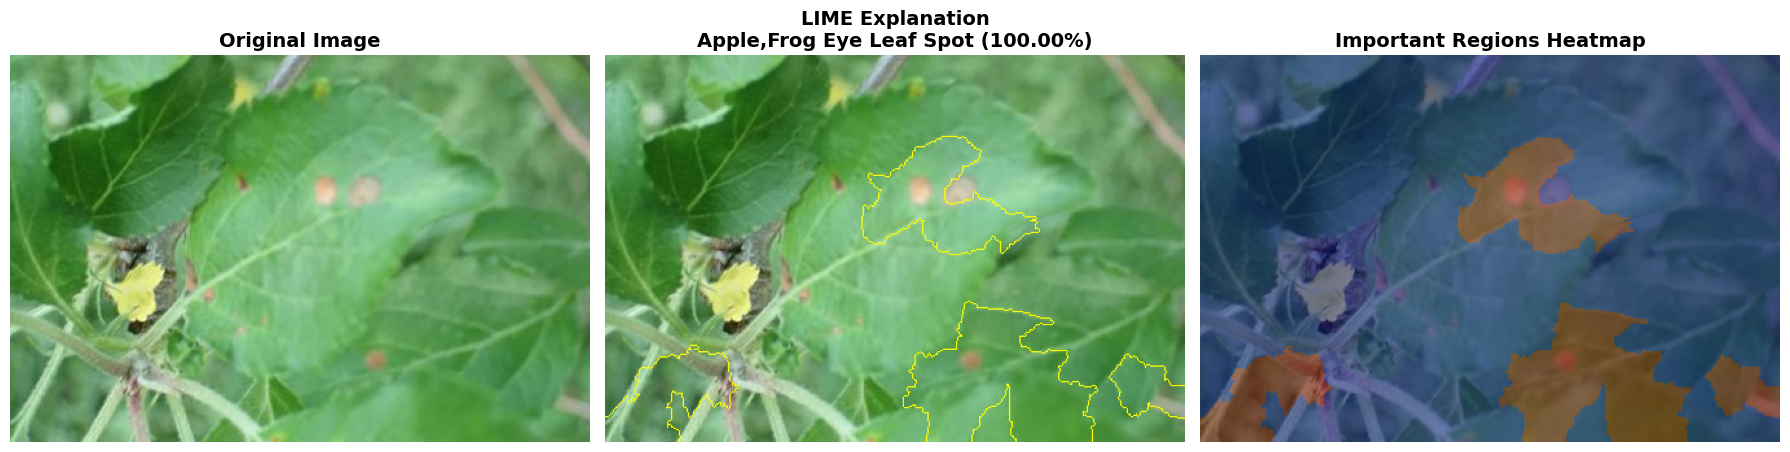

In [9]:
temp, mask = explanation.get_image_and_mask(
    predicted_class_idx,
    positive_only=True,
    num_features=10,
    hide_rest=False
)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(image)
axes[0].set_title(f'Original Image', fontsize=14, fontweight='bold')
axes[0].axis('off')

axes[1].imshow(mark_boundaries(temp / 255.0, mask))
axes[1].set_title(f'LIME Explanation\n{predicted_label} ({confidence:.2%})', 
                 fontsize=14, fontweight='bold')
axes[1].axis('off')

axes[2].imshow(image)
axes[2].imshow(mask, cmap='jet', alpha=0.5)
axes[2].set_title(f'Important Regions Heatmap', fontsize=14, fontweight='bold')
axes[2].axis('off')

plt.tight_layout()
plt.show()